# Semana 5 — Dataset procesado

## Limpieza y transformación de datos

En este notebook se continúa el trabajo realizado en el reconocimiento inicial del dataset.

El objetivo es aplicar las técnicas solicitadas:

- Manejo de valores nulos.
- Detección de outliers en `Ingresos` usando el método IQR.
- Normalización de `Ingresos` con Min-Max Scaling.
- Estandarización de `Edad` con Z-score Scaling.
- One-Hot Encoding para `Historial_Pagos`.
- Label Encoding para `Categoría`.

Este proceso permite dejar el dataset preparado para un posible modelo de predicción de solvencia financiera.


In [1]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns


## 1. Creación del dataset original

Se utiliza el dataset indicado en la actividad de la Semana 5.

El conjunto de datos representa clientes bancarios con información sobre edad, ingresos, historial de pagos y categoría.


In [2]:
df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Historial_Pagos": ["Bueno", "Regular", "Malo", "Bueno", "Regular", "Malo", "Bueno", "Regular"],
    "Categoría": ["A", "B", "C", "A", "B", "C", "A", "B"]
})

df


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


## 2. Revisión inicial de valores nulos

Antes de transformar los datos, se verifica si existen valores faltantes en las columnas `Edad` o `Ingresos`.

La consigna pide identificar y manejar valores nulos en esas variables.


In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Cliente            0
Edad               0
Ingresos           0
Historial_Pagos    0
Categoría          0
dtype: int64


### Interpretación

El dataset no presenta valores nulos.

De todas formas, se aplica una estrategia de imputación con la mediana en las columnas numéricas. Esto mantiene coherencia con la consigna de limpieza de datos y evita errores si aparecieran valores faltantes en una versión futura del dataset.


In [4]:
df_limpio = df.copy()

# Imputación con mediana para columnas numéricas
df_limpio.fillna(df_limpio.median(numeric_only=True), inplace=True)

print("Valores nulos después de la limpieza:")
print(df_limpio.isnull().sum())


Valores nulos después de la limpieza:
Cliente            0
Edad               0
Ingresos           0
Historial_Pagos    0
Categoría          0
dtype: int64


## 3. Detección de outliers en Ingresos con el método IQR

El método IQR permite detectar valores atípicos usando el rango intercuartílico.

Se calculan:

- Q1: primer cuartil.
- Q3: tercer cuartil.
- IQR: diferencia entre Q3 y Q1.
- Límite inferior: Q1 - 1.5 × IQR.
- Límite superior: Q3 + 1.5 × IQR.

Los valores fuera de esos límites se consideran posibles outliers.


In [5]:
Q1 = df_limpio["Ingresos"].quantile(0.25)
Q3 = df_limpio["Ingresos"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)


Q1: 49500.0
Q3: 74000.0
IQR: 24500.0
Límite inferior: 12750.0
Límite superior: 110750.0


In [6]:
outliers = df_limpio[
    (df_limpio["Ingresos"] < limite_inferior) |
    (df_limpio["Ingresos"] > limite_superior)
]

print("Outliers detectados en Ingresos:")
outliers


Outliers detectados en Ingresos:


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría


### Interpretación

No se detectaron outliers en la columna `Ingresos` usando el método IQR.

Por lo tanto, no se eliminan registros. El dataset conserva sus 8 clientes originales.


In [7]:
df_cleaned = df_limpio[
    (df_limpio["Ingresos"] >= limite_inferior) &
    (df_limpio["Ingresos"] <= limite_superior)
].copy()

print("Cantidad de registros antes de filtrar outliers:", len(df_limpio))
print("Cantidad de registros después de filtrar outliers:", len(df_cleaned))

df_cleaned


Cantidad de registros antes de filtrar outliers: 8
Cantidad de registros después de filtrar outliers: 8


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


## 4. Comparación visual de Ingresos antes y después del tratamiento de outliers

Como no se detectaron outliers, la distribución se mantiene igual. Aun así, se muestran los gráficos para dejar evidencia del proceso.


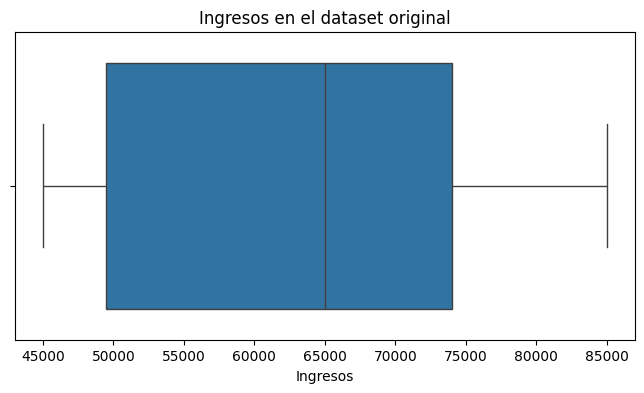

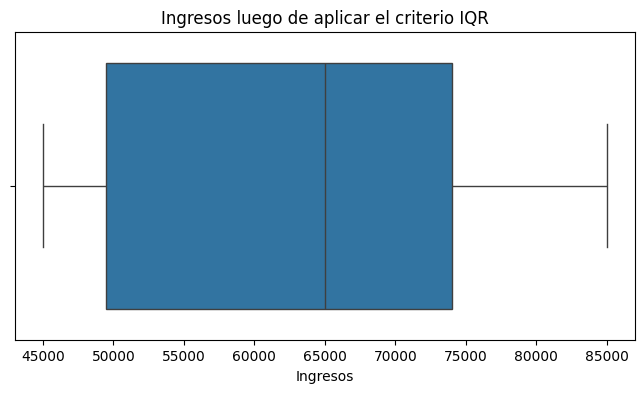

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_limpio["Ingresos"])
plt.title("Ingresos en el dataset original")
plt.xlabel("Ingresos")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_cleaned["Ingresos"])
plt.title("Ingresos luego de aplicar el criterio IQR")
plt.xlabel("Ingresos")
plt.show()


## 5. Normalización de Ingresos con Min-Max Scaling

La normalización transforma los valores de una variable numérica para que queden en un rango entre 0 y 1.

Esto es útil cuando una variable tiene valores mucho más grandes que otras y podría influir demasiado en un modelo de Machine Learning.


In [9]:
scaler_minmax = MinMaxScaler()

df_cleaned["Ingresos_Normalizado"] = scaler_minmax.fit_transform(df_cleaned[["Ingresos"]])

df_cleaned[["Cliente", "Ingresos", "Ingresos_Normalizado"]]


,Cliente,Ingresos,Ingresos_Normalizado
0,1,50000,0.125
1,2,60000,0.375
2,3,70000,0.625
3,4,80000,0.875
4,5,45000,0.000
5,6,85000,1.000
6,7,72000,0.675
7,8,48000,0.075


### Interpretación

Después de la normalización:

- El ingreso más bajo queda representado como 0.
- El ingreso más alto queda representado como 1.
- Los demás valores quedan ubicados proporcionalmente entre 0 y 1.

Esto permite comparar `Ingresos` con otras variables sin que su escala original domine el análisis.


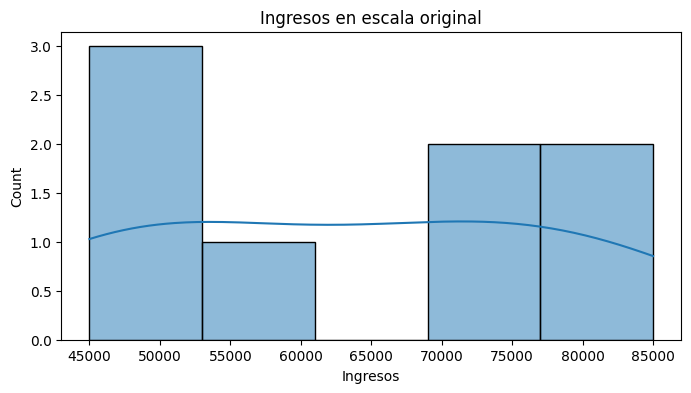

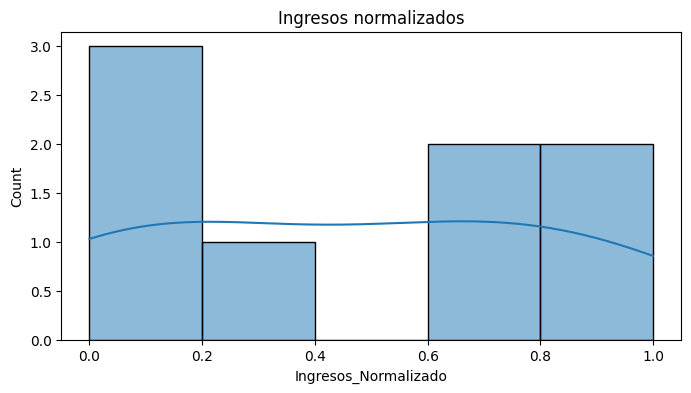

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned["Ingresos"], bins=5, kde=True)
plt.title("Ingresos en escala original")
plt.xlabel("Ingresos")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned["Ingresos_Normalizado"], bins=5, kde=True)
plt.title("Ingresos normalizados")
plt.xlabel("Ingresos_Normalizado")
plt.show()


## 6. Estandarización de Edad con Z-score Scaling

La estandarización transforma una variable para que tenga:

- Media cercana a 0.
- Desviación estándar cercana a 1.

Esto es útil para modelos sensibles a la escala de las variables.


In [11]:
scaler_standard = StandardScaler()

df_cleaned["Edad_Estandarizada"] = scaler_standard.fit_transform(df_cleaned[["Edad"]])

df_cleaned[["Cliente", "Edad", "Edad_Estandarizada"]]


,Cliente,Edad,Edad_Estandarizada
0,1,25,-1.451747
1,2,40,0.441836
2,3,35,-0.189358
3,4,50,1.704225
4,5,30,-0.820553
5,6,45,1.073030
6,7,38,0.189358
7,8,29,-0.946792


### Interpretación

Después de estandarizar `Edad`:

- Los valores positivos indican edades por encima del promedio.
- Los valores negativos indican edades por debajo del promedio.
- Los valores cercanos a 0 indican edades cercanas a la media del grupo.


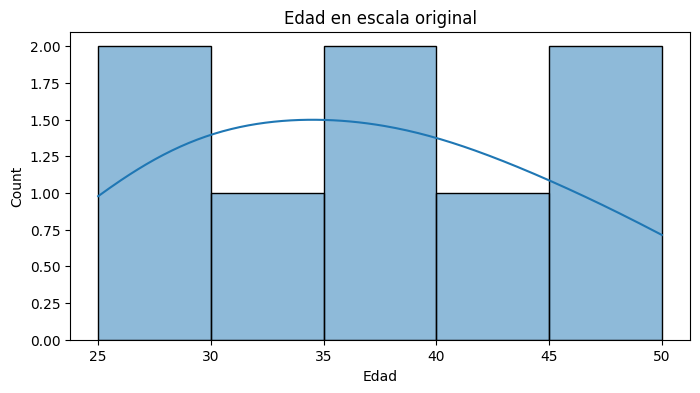

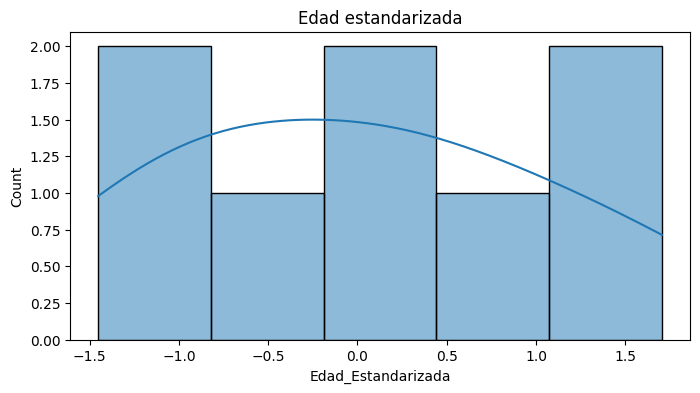

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned["Edad"], bins=5, kde=True)
plt.title("Edad en escala original")
plt.xlabel("Edad")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned["Edad_Estandarizada"], bins=5, kde=True)
plt.title("Edad estandarizada")
plt.xlabel("Edad_Estandarizada")
plt.show()


## 7. Codificación de Historial_Pagos con One-Hot Encoding

`Historial_Pagos` es una variable categórica sin orden numérico obligatorio.

Por eso se aplica One-Hot Encoding, que crea una columna binaria para cada categoría:

- `Historial_Bueno`
- `Historial_Malo`
- `Historial_Regular`

Cada columna indica con `True` o `False` si el cliente pertenece a esa categoría.


In [13]:
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=["Historial_Pagos"],
    prefix="Historial"
)

df_encoded.head()


,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular
0,1,25,50000,A,0.125,-1.451747,True,False,False
1,2,40,60000,B,0.375,0.441836,False,False,True
2,3,35,70000,C,0.625,-0.189358,False,True,False
3,4,50,80000,A,0.875,1.704225,True,False,False
4,5,30,45000,B,0.000,-0.820553,False,False,True


### Interpretación

One-Hot Encoding evita asignar un orden artificial a categorías como `Bueno`, `Regular` y `Malo`.

Esto es importante porque algunos modelos podrían interpretar números como jerarquías si se usara una codificación incorrecta.


## 8. Codificación de Categoría con Label Encoding

La consigna pide aplicar Label Encoding a la columna `Categoría`.

Label Encoding asigna un número a cada clase:

- A → 0
- B → 1
- C → 2

Esta técnica es simple y permite convertir una variable de texto en una variable numérica.


In [14]:
le = LabelEncoder()

df_encoded["Categoría_Label"] = le.fit_transform(df_encoded["Categoría"])

df_encoded[["Cliente", "Categoría", "Categoría_Label"]]


,Cliente,Categoría,Categoría_Label
0,1,A,0
1,2,B,1
2,3,C,2
3,4,A,0
4,5,B,1
5,6,C,2
6,7,A,0
7,8,B,1


## 9. Dataset final transformado

A continuación se muestra el dataset final luego de aplicar limpieza y transformación.


In [15]:
df_final = df_encoded.copy()

df_final


,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoría_Label
0,1,25,50000,A,0.125,-1.451747,True,False,False,0
1,2,40,60000,B,0.375,0.441836,False,False,True,1
2,3,35,70000,C,0.625,-0.189358,False,True,False,2
3,4,50,80000,A,0.875,1.704225,True,False,False,0
4,5,30,45000,B,0.000,-0.820553,False,False,True,1
5,6,45,85000,C,1.000,1.073030,False,True,False,2
6,7,38,72000,A,0.675,0.189358,True,False,False,0
7,8,29,48000,B,0.075,-0.946792,False,False,True,1


## 10. Comparación entre dataset original y dataset procesado

Esta comparación permite observar el cambio entre el dataset inicial y el dataset preparado.


In [16]:
print("Dataset original:")
display(df)

print("Dataset procesado:")
display(df_final)


Dataset original:


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


Dataset procesado:


,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoría_Label
0,1,25,50000,A,0.125,-1.451747,True,False,False,0
1,2,40,60000,B,0.375,0.441836,False,False,True,1
2,3,35,70000,C,0.625,-0.189358,False,True,False,2
3,4,50,80000,A,0.875,1.704225,True,False,False,0
4,5,30,45000,B,0.000,-0.820553,False,False,True,1
5,6,45,85000,C,1.000,1.073030,False,True,False,2
6,7,38,72000,A,0.675,0.189358,True,False,False,0
7,8,29,48000,B,0.075,-0.946792,False,False,True,1


## 11. Ventajas y desventajas de las codificaciones utilizadas

### One-Hot Encoding

**Ventaja:**  
No introduce un orden artificial entre las categorías.

**Desventaja:**  
Puede aumentar mucho la cantidad de columnas si hay muchas categorías.

### Label Encoding

**Ventaja:**  
Es simple y genera una sola columna numérica.

**Desventaja:**  
Puede introducir un orden artificial si las categorías no tienen jerarquía real.


## 12. Consulta a una herramienta LLM

Consulta realizada:

> ¿Qué métodos avanzados de imputación de datos recomiendas para conjuntos de datos con muchas variables numéricas y categóricas?

Respuesta sintetizada:

Una herramienta LLM puede recomendar métodos como KNN Imputer, imputación por regresión o MICE. Estos métodos intentan estimar los valores faltantes usando relaciones entre variables, en lugar de reemplazarlos solamente por media, mediana o moda.

Validación propia:

En este dataset no fue necesario aplicar imputación avanzada porque no existían valores nulos. Sin embargo, en datasets reales más grandes, estos métodos pueden ser útiles cuando los valores faltantes no son aleatorios y existe relación entre las variables.


## 13. Conclusión final

Se aplicó el proceso de limpieza y transformación solicitado.

Conclusiones principales:

1. No se detectaron valores nulos en el dataset.
2. No se detectaron outliers en `Ingresos` mediante el método IQR.
3. `Ingresos` fue normalizado con Min-Max Scaling, quedando en una escala entre 0 y 1.
4. `Edad` fue estandarizada con Z-score Scaling, permitiendo interpretar edades respecto de la media.
5. `Historial_Pagos` fue transformado con One-Hot Encoding.
6. `Categoría` fue transformada con Label Encoding.
7. El dataset final queda preparado para ser utilizado en un modelo de predicción de solvencia financiera.

La transformación mejora la calidad del dataset porque convierte variables categóricas en numéricas y ajusta las escalas de las variables, lo cual facilita el trabajo posterior con modelos de Machine Learning.
